# ch11 · 熵、KL 散度、互信息、交叉熵

## Why this chapter
机器学习的核心 loss 函数 (cross-entropy、KL、ELBO) 都来自信息论. 这一章帮你看到"为什么分类用 CE""为什么 ELBO = -KL - NLL""互信息和相关哪个有用".

## 学完后能解决

- 计算 Shannon 熵与互信息闭式解
- 推 KL 不对称 + 链式法则 + 非负
- 实现数值稳定的 KL 与 MI 估计
- 用 MI 做特征筛选 (与 correlation 对比)
- 把 ELBO 拆成 -KL - NLL 一行写


## 2. 直觉: 抛硬币的比特数

抛一枚均匀硬币 → 1 bit 信息. 抛一枚 p=0.99 偏硬币 → 几乎 0 bit (无新信息, 因已能预测).
"惊讶程度" $= \log_2 1/p(x)$; 平均 = $H[X] = -\sum p(x) \log p(x)$.


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29109 (\N{CJK UNIFIED IDEOGRAPH-71B5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


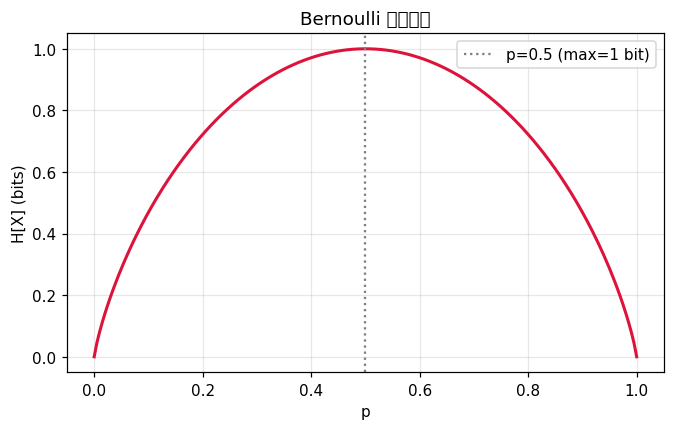

H(p=0.5) = 1.0000 bits
H(p=0.99)= 0.0808 bits
H(p=0.01)= 同 H(0.99) (0.0808)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

ps = np.linspace(1e-6, 1-1e-6, 200)
# H[Bernoulli(p)] = -p log p - (1-p) log(1-p)
H = -ps * np.log2(ps) - (1-ps) * np.log2(1-ps)
fig, ax = plt.subplots(figsize=(7, 4), dpi=110)
ax.plot(ps, H, color="crimson", lw=2)
ax.axvline(0.5, ls=":", color="gray", label="p=0.5 (max=1 bit)")
ax.set_xlabel("p"); ax.set_ylabel("H[X] (bits)")
ax.set_title("Bernoulli 分布的熵")
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()
print(f"H(p=0.5) = {-0.5*np.log2(0.5) - 0.5*np.log2(0.5):.4f} bits")
print(f"H(p=0.99)= {-0.99*np.log2(0.99) - 0.01*np.log2(0.01):.4f} bits")
print(f"H(p=0.01)= 同 H(0.99) ({-0.01*np.log2(0.01) - 0.99*np.log2(0.99):.4f})")


## 3. 公式

### Shannon 熵
$H[X] = -\sum_x p(x) \log p(x)$  (离散, 单位 bits 当底数 2; nats 当底数 e)

### Joint 熵
$H[X, Y] = -\sum_{x,y} p(x,y)\log p(x,y)$

### 条件熵
$H[Y | X] = \sum_x p(x) H[Y | X=x] = H[X, Y] - H[X]$

### 互信息 (Mutual Information)
$$I[X; Y] = H[X] - H[X | Y] = H[Y] - H[Y | X] = H[X] + H[Y] - H[X, Y]$$

### KL 散度
$D_{KL}(p \| q) = \sum_x p(x) \log \frac{p(x)}{q(x)} \ge 0$

### 交叉熵
$H(p, q) = -\sum p(x)\log q(x) = H(p) + D_{KL}(p \| q)$

### 链式法则
- $H[X, Y] = H[X] + H[Y | X]$
- $D_{KL}(p(x,y) \| q(x,y)) = D_{KL}(p(x)\|q(x)) + D_{KL}(p(y|x)\|q(y|x))$

### 关键性质
- KL ≥ 0, 等号 iff p = q (Jensen)
- KL 非对称: D(p‖q) ≠ D(q‖p)
- 互信息 = 0 ⇔ X, Y 独立


## 4. 符号推导: KL 非负 (Jensen)


In [2]:
import sympy as sp
# KL >= 0 由 -log 凸性: -E_p[log (q/p)] >= -log E_p[q/p] = -log 1 = 0
x, y = sp.symbols("x y", positive=True)
# 取个具体例: p = (1/2, 1/2), q = (1/4, 3/4)
p_arr = [sp.Rational(1, 2), sp.Rational(1, 2)]
q_arr = [sp.Rational(1, 4), sp.Rational(3, 4)]
D_pq = sum(p * sp.log(p / q) for p, q in zip(p_arr, q_arr))
D_qp = sum(q * sp.log(q / p) for p, q in zip(p_arr, q_arr))
print(f"D(p||q) = {D_pq} = {float(D_pq):.4f} nats")
print(f"D(q||p) = {D_qp} = {float(D_qp):.4f} nats (非对称)")
print(f"D(p||q) 非负: {(D_pq >= 0)}")


D(p||q) = log(2/3)/2 + log(2)/2 = 0.1438 nats
D(q||p) = -log(2)/4 + 3*log(3/2)/4 = 0.1308 nats (非对称)
D(p||q) 非负: True


## 5. 数值验证: MI 独立 ⇒ 0


In [3]:
import numpy as np
rng = np.random.default_rng(seed=20240717)
N = 10000
# Case A: 独立 X, Y
X = rng.normal(0, 1, N); Y = rng.normal(0, 1, N)
# Discretize 到 20 bins 估 MI
def mi_discrete(x, y, n_bins=20):
    cx = np.histogram(x, n_bins)[0]; px = cx / cx.sum()
    cy = np.histogram(y, n_bins)[0]; py = cy / cy.sum()
    joint, _, _ = np.histogram2d(x, y, n_bins)
    pxy = joint / joint.sum()
    return np.sum(pxy[pxy > 0] * np.log(pxy[pxy > 0] / (px[:, None] * py[None, :])[pxy > 0]))

print(f"Case A (独立) MI = {mi_discrete(X, Y):.4f}  (期望 ~0)")
# Case B: Y = X + noise
Y2 = X + 0.1 * rng.normal(0, 1, N)
print(f"Case B (Y=X+ε) MI = {mi_discrete(X, Y2):.4f}  (应显著大)")
# Case C: Y = X² 独立 (ѿ但非线性依赖)
Y3 = X**2 + 0.05 * rng.normal(0, 1, N)
print(f"Case C (Y=X²) MI = {mi_discrete(X, Y3):.4f}, Corr={np.corrcoef(X, Y3)[0,1]:.3f}")
print("案例 C 显示 MI 抓住非线性依赖, 而 Corr 几乎 0.")


Case A (独立) MI = 0.0138  (期望 ~0)
Case B (Y=X+ε) MI = 1.7309  (应显著大)
Case C (Y=X²) MI = 0.9510, Corr=-0.008
案例 C 显示 MI 抓住非线性依赖, 而 Corr 几乎 0.


## 6. 可视化: 不同分布的 CE


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-

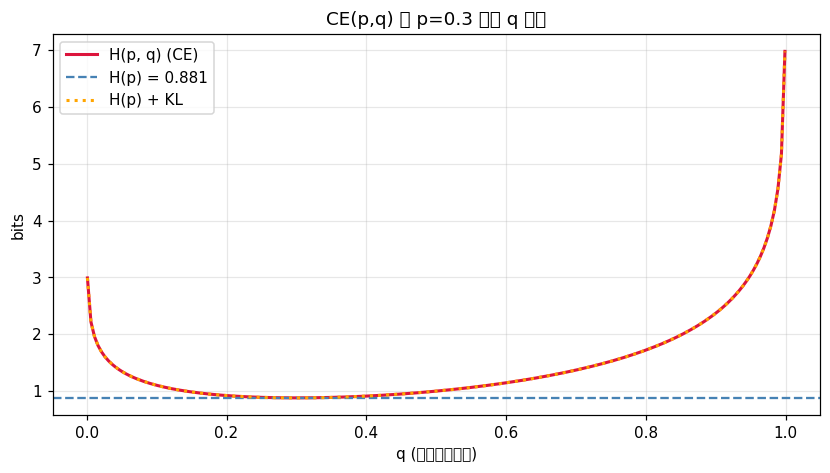

当 q=p=0.3 时 CE 最小 = 0.8813


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import rel_entr

# Bernoulli: CE(p, q) = H(p) + KL(p||q). 当 p=q 时 CE = H(p); 否则 CE > H
p_true = 0.3
q_arr = np.linspace(0.001, 0.999, 200)
H_p = -p_true * np.log2(p_true) - (1-p_true) * np.log2(1-p_true)
CE = -p_true * np.log2(q_arr) - (1-p_true) * np.log2(1-q_arr)
KL_arr = CE - H_p
fig, ax = plt.subplots(figsize=(9, 4.5), dpi=110)
ax.plot(q_arr, CE, color="crimson", lw=2, label="H(p, q) (CE)")
ax.axhline(H_p, ls="--", color="steelblue", label=f"H(p) = {H_p:.3f}")
ax.plot(q_arr, KL_arr + H_p, ls=":", color="orange", lw=2, label="H(p) + KL")
ax.set_xlabel("q (模型预测概率)"); ax.set_ylabel("bits")
ax.set_title(f"CE(p,q) 在 p={p_true} 时随 q 变化"); ax.legend(); ax.grid(True, alpha=0.3)
plt.show()
print(f"当 q=p=0.3 时 CE 最小 = {H_p:.4f}")


## 7. 工程案例: 互信息特征筛选


In [5]:
import numpy as np
rng = np.random.default_rng(seed=20240717)
N = 2000; D = 10
X = rng.normal(0, 1, size=(N, D))
y = (X[:, 0] + 0.5 * X[:, 2] - X[:, 5] + rng.normal(0, 0.3, N) > 0).astype(int)

def mi_xy(x, y, n_bins=10):
    cx, *_ = np.histogram(x, n_bins); px = cx / cx.sum()
    cy, *_ = np.histogram(y, 2); py = cy / cy.sum()
    joint, _, _ = np.histogram2d(x, y, [n_bins, 2])
    pxy = joint / joint.sum()
    pxy_safe = pxy[pxy > 0]; outer_safe = (px[:, None] * py[None, :])[pxy > 0]
    return np.sum(pxy_safe * np.log(pxy_safe / outer_safe))

mis = [mi_xy(X[:, d], y) for d in range(D)]
corrs = [abs(np.corrcoef(X[:, d], y)[0, 1]) for d in range(D)]
print(f"{'feature':>8} {'MI':>10} {'|corr|':>10}  (true signal = x0, x2, x5)")
for d in range(D):
    print(f"feat[{d}] {mis[d]:>10.4f} {corrs[d]:>10.4f}")
# 排序 top-3:
top3_mi = np.argsort(mis)[::-1][:3]
top3_corr = np.argsort(corrs)[::-1][:3]
print("MI  top-3:", top3_mi)
print("|corr| top-3:", top3_corr)
print("True 信号: indices 0, 2, 5")


 feature         MI     |corr|  (true signal = x0, x2, x5)
feat[0]     0.1552     0.5203
feat[1]     0.0006     0.0158
feat[2]     0.0360     0.2629
feat[3]     0.0018     0.0111
feat[4]     0.0035     0.0123
feat[5]     0.1475     0.5097
feat[6]     0.0013     0.0110
feat[7]     0.0008     0.0378
feat[8]     0.0028     0.0250
feat[9]     0.0022     0.0052
MI  top-3: [0 5 2]
|corr| top-3: [0 5 2]
True 信号: indices 0, 2, 5


## 8. pitfalls
- 用 `np.log` 时出现 p=0 → 用 `np.log(p + eps)` 或 `rel_entr` 避 NaN
- D_KL 不对称, VAE 用 forward D(q||p) (mode-covering); EM 用 reverse
- KL 链式法则 × 链式分解 大部分教材混用, 准确为 KL(p(x,y)||q(x,y)) = KL(p(x)||q(x)) + KL(p(y|x)||q(y|x))
- 互信息在 0 处退化但 在高维 sample 偏; 用 KSG estimator 更稳
- CE = H(p) + KL(p||q); 但实际 ML 中 H(p) is constant wrt 模型 → minimize CE == minimize KL

## 9. 课后 -> exercises.md

## 10. 参考
| 出处 | 章节 |
|---|---|
| MacKay | Ch.2-4 |
| Cover & Thomas | Ch.2-7 |
| Murphy | §2.3 (信息部分) |

下一章 ch12 进入贝叶斯推断 PyMC 实跑.
